## imports y carga de datos

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset/strava_data.csv')

## Analisis exploratorio de datos

In [233]:
# Filtramos por el tipo de deporte que queremos, ride = ciclismo
df = df[df['sport_type'] == 'Ride']

# Columnas que necesitamos
df = df[[
    "name",
    "distance",
    "moving_time",
    "total_elevation_gain",
    "average_speed",
    "sport_type",
    "date"
]]

# Verificamos datos nulos
df.isnull().sum()

# Verificamos duplicados y los eliminamos
df.duplicated().sum()
df = df.drop_duplicates()

df = df[df["average_speed"] > 5]   # elimina registros casi estáticos
df = df[df["average_speed"] < 60]  # elimina velocidades imposibles

# Convertimos las unidades de medida
# millas -> km
df["distance"] = df["distance"] * 1.60934

# millas por hora -> km/h
df["average_speed"] = df["average_speed"] * 1.60934

# pies -> metros
df["total_elevation_gain"] = df["total_elevation_gain"] * 0.3048

# convertir date de string a tipo fecha
df["date"] = pd.to_datetime(df["date"])

# Renombrar columnas
df = df.rename(columns={
    "distance": "distance_km",
    "average_speed": "average_speed_kmh",
    "total_elevation_gain": "elevation_m"
})

df["distance_km"] = df["distance_km"].round(2)
df["average_speed_kmh"] = df["average_speed_kmh"].round(2)
df["elevation_m"] = df["elevation_m"].round(2)

df.head()

,name,distance_km,moving_time,elevation_m,average_speed_kmh,sport_type,date
8,bikini,80.55,168.63,1040.0,28.66,Ride,2023-08-19 06:29:26
15,Evening Ride,3.44,13.15,19.0,15.71,Ride,2023-08-13 19:39:30
17,Morning Ride,0.53,1.47,1.0,21.60,Ride,2023-08-12 10:21:07
18,shift in the force,80.80,158.72,404.0,30.55,Ride,2023-08-12 07:31:32
24,Fresh Daily,76.70,156.75,722.0,29.35,Ride,2023-08-05 07:00:43


In [234]:
df.describe()

,distance_km,moving_time,elevation_m,average_speed_kmh,date
count,495.000000,495.000000,495.000000,495.000000,495
mean,37.069960,80.491737,235.819394,25.702364,2021-02-09 22:13:00.024242
min,0.060000,0.250000,0.000000,8.420000,2017-04-26 18:49:11
25%,13.890000,37.290000,23.500000,22.235000,2020-06-17 10:07:06.500000
50%,32.200000,70.000000,133.200000,27.390000,2021-05-14 06:00:42
75%,56.775000,121.065000,365.000000,30.060000,2022-01-17 08:08:32.500000
max,161.380000,309.800000,1648.000000,45.930000,2023-08-19 06:29:26
std,27.151165,52.563744,284.921816,6.689752,NaN


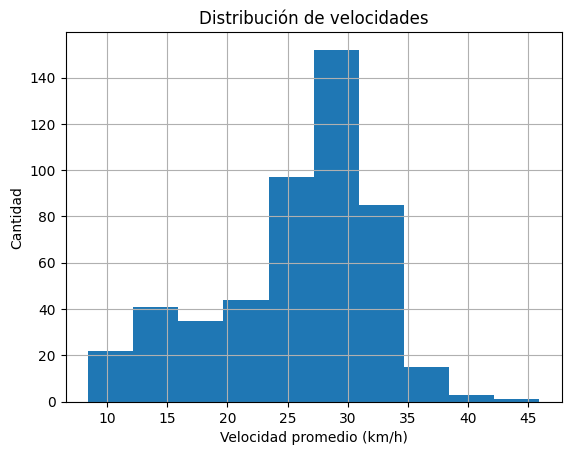

In [235]:
df["average_speed_kmh"].hist()

plt.xlabel("Velocidad promedio (km/h)")
plt.ylabel("Cantidad")
plt.title("Distribución de velocidades")
plt.show()

### La mayoría de ciclistas están entre: 20 y 35 km/h

### Se identificaron valores atípicos en la velocidad promedio, posiblemente causados por errores de medición o registros anómalos.

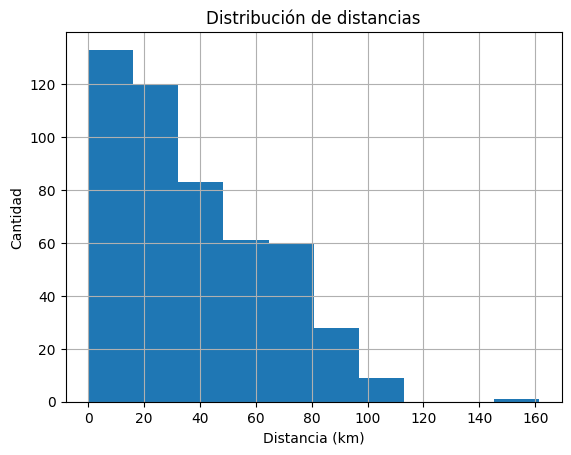

In [236]:
df["distance_km"].hist()

plt.xlabel("Distancia (km)")
plt.ylabel("Cantidad")
plt.title("Distribución de distancias")
plt.show()

### Que muestra este grafico?
#### La mayoría de rutas están entre: 0 y 40 km
#### Entonces la mayoría son recorridos cortos o medios pocas rutas son extremadamente largas

## Clasificacion de medidas

In [237]:
speed_conditions = [
    df["average_speed_kmh"] < 20,
    (df["average_speed_kmh"] >= 20) & (df["average_speed_kmh"] < 30),
    df["average_speed_kmh"] >= 30
]

speed_ranges = ["< 20 km/h", "20–30 km/h", "> 30 km/h"]
levels = ["Beginner", "Intermediate", "Advanced"]

df = df.assign(
    speed_range=np.select(speed_conditions, speed_ranges, default="unknown"),
    level=np.select(speed_conditions, levels, default="unknown")
)

df.head()

,name,distance_km,moving_time,elevation_m,average_speed_kmh,sport_type,date,speed_range,level
8,bikini,80.55,168.63,1040.0,28.66,Ride,2023-08-19 06:29:26,20–30 km/h,Intermediate
15,Evening Ride,3.44,13.15,19.0,15.71,Ride,2023-08-13 19:39:30,< 20 km/h,Beginner
17,Morning Ride,0.53,1.47,1.0,21.60,Ride,2023-08-12 10:21:07,20–30 km/h,Intermediate
18,shift in the force,80.80,158.72,404.0,30.55,Ride,2023-08-12 07:31:32,> 30 km/h,Advanced
24,Fresh Daily,76.70,156.75,722.0,29.35,Ride,2023-08-05 07:00:43,20–30 km/h,Intermediate


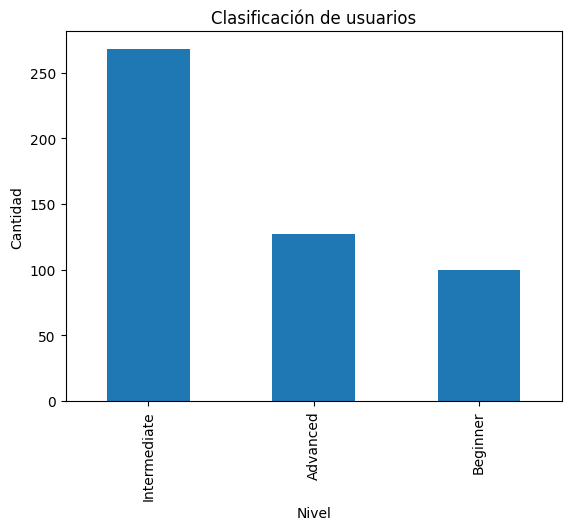

In [238]:

df["level"].value_counts().plot(kind="bar")

plt.xlabel("Nivel")
plt.ylabel("Cantidad")
plt.title("Clasificación de usuarios")
plt.show()

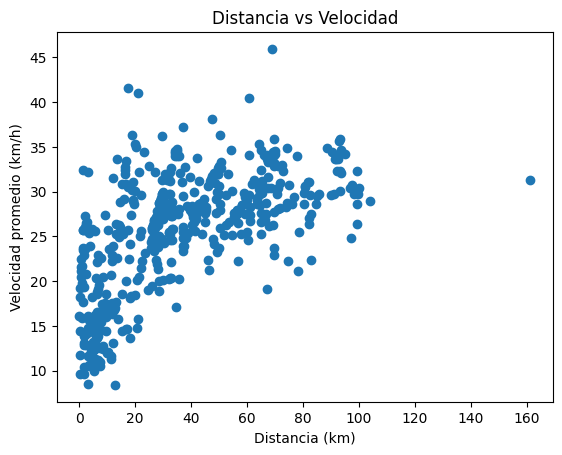

In [239]:
plt.scatter(
    df["distance_km"],
    df["average_speed_kmh"]
)

plt.xlabel("Distancia (km)")
plt.ylabel("Velocidad promedio (km/h)")
plt.title("Distancia vs Velocidad")

plt.show()

## Que nos dice este scatter plot? el comportamiento real de los ciclistas
Zona 0–20 km (izquierda): dispersión vertical enorme, velocidades de 8 a 42 km/h. Tiene sentido: Rutas cortas las hacen tanto principiantes como avanzados, unos entrenando intervalos intensos, otros dando un paseo.

Zona 20–60 km (centro): la nube se compacta y sube. La mayoría converge entre 25–35 km/h. Aquí están los ciclistas más consistentes, rutas medias con un perfil de esfuerzo más estable.

Zona 60–160 km (derecha): muy pocos puntos pero todos en el rango 25–35 km/h. Esto es clave: los ciclistas de larga distancia no son necesariamente los más rápidos, mantienen una velocidad eficiente para aguantar el esfuerzo prolongado.

En conclusion la velocidad y distancia no tienen una correlación lineal fuerte. Un ciclista rápido no siempre hace rutas largas, y uno de larga distancia no siempre es el más veloz. 


## Normalizacion

imagina una ruta con:

distance_km = 80 km
elevation_m = 600 m
average_speed_km/h = 30 km/h

Si simplemente sumas esos números con pesos, la elevación (600) va a dominar el score solo por ser un número grande, no porque sea más importante. Los números están en escalas completamente distintas.


La normalización lo que hace es llevar todo al mismo idioma: del 0 al 1.
La fórmula es simple, se llama Min-Max:


valor_normalizado = (valor - mínimo) / (máximo - mínimo)

La idea del scoring es asignarle a cada ruta un puntaje de dificultad del 0 al 1 combinando las 3 variables con pesos distintos, porque no todas importan igual:

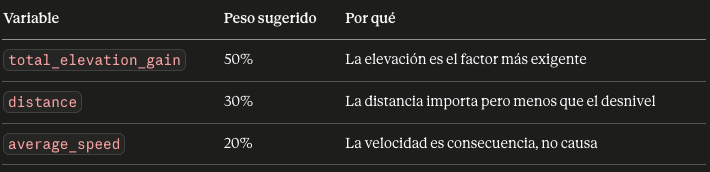


Cada variable se normaliza del 0 al 1 primero (para que no dominen las que tienen números grandes), y luego se multiplica por su peso:


score = (elev_norm × 0.5) + (dist_norm × 0.3) + (speed_norm × 0.2)
Después divides ese score en rangos:

0.0 – 0.33 → recomiéndalo a Beginner
0.33 – 0.66 → recomiéndalo a Intermediate
0.66 – 1.0 → recomiéndalo a Advanced

In [240]:
df = df.assign(
    elev_norm=(df["elevation_m"] - df["elevation_m"].min()) /
              (df["elevation_m"].max() - df["elevation_m"].min()),

    dist_norm=(df["distance_km"] - df["distance_km"].min()) /
              (df["distance_km"].max() - df["distance_km"].min()),

    speed_norm=(df["average_speed_kmh"] - df["average_speed_kmh"].min()) /
               (df["average_speed_kmh"].max() - df["average_speed_kmh"].min())
)

df.head()

,name,distance_km,moving_time,elevation_m,average_speed_kmh,sport_type,date,speed_range,level,elev_norm,dist_norm,speed_norm
8,bikini,80.55,168.63,1040.0,28.66,Ride,2023-08-19 06:29:26,20–30 km/h,Intermediate,0.631068,0.498946,0.539589
15,Evening Ride,3.44,13.15,19.0,15.71,Ride,2023-08-13 19:39:30,< 20 km/h,Beginner,0.011529,0.020952,0.194348
17,Morning Ride,0.53,1.47,1.0,21.60,Ride,2023-08-12 10:21:07,20–30 km/h,Intermediate,0.000607,0.002913,0.351373
18,shift in the force,80.80,158.72,404.0,30.55,Ride,2023-08-12 07:31:32,> 30 km/h,Advanced,0.245146,0.500496,0.589976
24,Fresh Daily,76.70,156.75,722.0,29.35,Ride,2023-08-05 07:00:43,20–30 km/h,Intermediate,0.438107,0.475081,0.557985


## Scoring ponderado

In [241]:
df = df.assign(
    difficulty_score=(
        df["elev_norm"] * 0.5 +
        df["dist_norm"] * 0.3 +
        df["speed_norm"] * 0.2
    )
)

df.head()

,name,distance_km,moving_time,elevation_m,average_speed_kmh,sport_type,date,speed_range,level,elev_norm,dist_norm,speed_norm,difficulty_score
8,bikini,80.55,168.63,1040.0,28.66,Ride,2023-08-19 06:29:26,20–30 km/h,Intermediate,0.631068,0.498946,0.539589,0.573136
15,Evening Ride,3.44,13.15,19.0,15.71,Ride,2023-08-13 19:39:30,< 20 km/h,Beginner,0.011529,0.020952,0.194348,0.050920
17,Morning Ride,0.53,1.47,1.0,21.60,Ride,2023-08-12 10:21:07,20–30 km/h,Intermediate,0.000607,0.002913,0.351373,0.071452
18,shift in the force,80.80,158.72,404.0,30.55,Ride,2023-08-12 07:31:32,> 30 km/h,Advanced,0.245146,0.500496,0.589976,0.390717
24,Fresh Daily,76.70,156.75,722.0,29.35,Ride,2023-08-05 07:00:43,20–30 km/h,Intermediate,0.438107,0.475081,0.557985,0.473174


## Funcion de recomendacion

In [ ]:
def recommend_routes(level, df):
    if level == "Beginner":
        routes = df[df["difficulty_score"] <= 0.33]
    elif level == "Intermediate":
        routes = df[(df["difficulty_score"] > 0.33) & (df["difficulty_score"] <= 0.66)]
    elif level == "Advanced":
        routes = df[df["difficulty_score"] > 0.66]
    else:
        print("Nivel no válido. Usa: Beginner, Intermediate o Advanced")
        return None

    return routes.sort_values("difficulty_score")[
        ["name", "distance_km", "average_speed_kmh", "elevation_m", "speed_range", "difficulty_score"]
    ].head(10)

## Pruebas de la funcion

In [243]:
print("\n=== Rutas para Advanced ===")
print(recommend_routes("Advanced", df))


=== Rutas para Advanced ===
                   name  distance_km  average_speed_kmh  elevation_m  \
974        Morning Ride        83.03              22.40       1426.0   
981        Morning Ride        78.39              21.10       1483.0   
1622  Zwift - The Gorby        23.11              34.38       1607.4   
649        Morning Ride        67.32              19.15       1648.0   
617      Hardman Gravel        97.27              24.77       1504.0   

      difficulty_score speed_range  
974           0.661482  20–30 km/h  
981           0.663215  20–30 km/h  
1622          0.668964   > 30 km/h  
649           0.682292   < 20 km/h  
617           0.724265  20–30 km/h  


In [244]:
print("\n=== Rutas para Intermediate ===")
print(recommend_routes("Intermediate", df))



=== Rutas para Intermediate ===
                   name  distance_km  average_speed_kmh  elevation_m  \
727        Morning Ride        59.85              29.10        358.9   
245            Fam ride        66.27              26.83        364.0   
465       Morning Ride         59.18              29.35        365.0   
421        Morning Ride        50.73              32.64        368.0   
1097       Morning Ride        69.80              32.85        252.0   
1654       Morning Ride        67.06              33.59        257.0   
1400       Morning Ride        40.20              27.65        527.0   
1638       Morning Ride        67.51              33.67        254.0   
1355       Morning Ride        41.12              29.98        482.0   
546   Chill Bill vol 1         55.84              27.54        435.0   

      difficulty_score speed_range  
727           0.330342  20–30 km/h  
245           0.331725  20–30 km/h  
465           0.332280  20–30 km/h  
421           0.335018   >

## Exportar CSV limpio

In [245]:
df.to_csv("dataset/strava_exported.csv", index=False)
print("Dataset exportado correctamente.")

Dataset exportado correctamente.
